__Student__: NGUYEN Sang <br>
__Lab__: Video Processing

# Video Analysis Smart Video Recorder using OpenCV

## VIDEO FILE MANAGEMENT AND VIDEO CUT DETECTION

### Import libraries

In [1]:
import os
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import namedtuple

### Data structure definition

In [2]:
Shot = namedtuple("Shot", ["id", "start_frame", "end_frame", "start_time", "end_time"])

### Mean absolute difference function

This function calculates the mean absolute difference between two frames, which is used to detect shot boundaries.

In [3]:
# compute mean absolute difference between two frames

def mean_abs_diff_between_frames(frame1_bgr, frame2_bgr):
    a = frame1_bgr.astype(np.float32)
    b = frame2_bgr.astype(np.float32)
    diff = np.mean(np.abs(a - b), axis=(0, 1))  # (B,G,R)
    return float(diff.sum())

### Plotting Mean Difference
We plot the mean frame difference to check shot boundaries (meaning the transition among shots)

In [4]:
def plot_meandiff_func(meandiff_frames, fps, diff_threshold,
                  out_path="meandiff_plot.png",
                  max_points=20000,
                  cut_frames=None,
                  dpi=200,
                  show=True,
                  block=True):
    if not meandiff_frames:
        print("No meandiff data to plot.")
        return None

    fps = float(fps) if fps and fps > 0 else 0.0

    if len(meandiff_frames) > max_points:
        step = int(np.ceil(len(meandiff_frames) / max_points))
        meandiff_frames = meandiff_frames[::step]

    frames = np.array([f for f, _ in meandiff_frames], dtype=np.int32)
    vals = np.array([v for _, v in meandiff_frames], dtype=np.float32)

    if fps > 0:
        x = frames / fps
        x_label = "Time (s)"
    else:
        x = frames.astype(np.float32)
        x_label = "Frame index"

    out_dir = os.path.dirname(out_path)
    if out_dir:
        os.makedirs(out_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(x, vals, linewidth=1.0, label="meandiff")
    ax.axhline(diff_threshold, linestyle="--", linewidth=1.0, label=f"threshold={diff_threshold}")

    if cut_frames:
        cut_frames = np.array(cut_frames, dtype=np.int32)
        cut_x = (cut_frames / fps) if fps > 0 else cut_frames.astype(np.float32)
        cut_x = np.unique(cut_x)
        for cx in cut_x:
            ax.axvline(cx, linewidth=0.5)

    ax.set_xlabel(x_label)
    ax.set_ylabel("Mean abs diff (BGR sum)")
    ax.set_title("Shot boundary score (meandiff) over time")
    ax.grid(True)
    ax.legend(loc="upper right")
    fig.tight_layout()

    fig.savefig(out_path, dpi=dpi, bbox_inches="tight")
    print("Saved meandiff plot to", out_path)

    if show:
        plt.show(block=block)

    plt.close(fig)
    return out_path


### This code implements a basic video shot analysis pipeline:

- Detects **shot boundaries** using mean frame differences.
- Splits the video into shots and optionally **saves each shot as a clip**.
- Analyzes each shot to estimate:
  - **court_ratio**: how much of the frame corresponds to the tennis court (based on hue),
  - **meandiff_mean**: average motion intensity within the shot.
- Summarizes all shot-level features and **exports them to a CSV file** for further analysis.


#### Function definition for video file management
- `try_open_writer` ensures the program can write an output video by trying several common codecs.
- `save_shot_clip` extracts a shot from the original video (from **start_frame** to **end_frame**) and saves it as a separate clip file in the output directory.
- `summarize_and_save` writes a CSV summary of all processed shots. For each shot, it saves the shot boundaries, the shot duration, and the computed features.

In [5]:
def try_open_writer(path, fps, size, candidates=("avc1", "H264", "X264", "mp4v")):
    W, H = size
    for four in candidates:
        fourcc = cv2.VideoWriter_fourcc(*four)
        writer = cv2.VideoWriter(path, fourcc, fps, (W, H))
        if writer.isOpened():
            return writer
        writer.release()
    return None

def save_shot_clip(video_path, shot, video_info, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    vcap = cv2.VideoCapture(video_path)
    if not vcap.isOpened():
        return None

    fps = video_info["fps"]
    W = video_info["width"]
    H = video_info["height"]

    out_path = os.path.join(out_dir, f"shot_{shot.id:03d}_{shot.start_frame:06d}_{shot.end_frame:06d}.mp4")
    writer = try_open_writer(out_path, fps, (W, H))
    if writer is None:
        print("Warning: could not open VideoWriter, skipping clip:", out_path)
        vcap.release()
        return None

    vcap.set(cv2.CAP_PROP_POS_FRAMES, shot.start_frame)
    for _ in range(shot.start_frame, shot.end_frame + 1):
        ret, frame = vcap.read()
        if not ret:
            break
        writer.write(frame)

    writer.release()
    vcap.release()
    return out_path

def summarize_and_save(shots_results, out_csv):
    keys = [
        "shot_id", "start_frame", "end_frame", "start_time", "end_time", "duration_s",
        "court_ratio", "meandiff_mean", "court_hue"
    ]
    with open(out_csv, "w", newline="") as fh:
        w = csv.writer(fh)
        w.writerow(keys)
        for s, r in shots_results:
            duration = s.end_time - s.start_time
            w.writerow([
                s.id, s.start_frame, s.end_frame,
                round(s.start_time, 3), round(s.end_time, 3), round(duration, 3),
                round(r["court_ratio"], 6),
                round(r["meandiff_mean"], 6),
                int(r["court_hue"])
            ])

#### Shot boundary detection using mean frame difference
This function detects shot boundaries by computing the mean absolute pixel difference between consecutive frames. If the difference exceeds **diff_threshold**, the frame is marked as a cut, and the resulting cut positions are converted into shot segments while enforcing a minimum shot length (**min_shot_length_frames**). It also returns the meandiff curve (**meandiff_series**) and basic video metadata for visualization and further analysis.

In [6]:
def detect_shot_boundaries(video_path, diff_threshold=100.0, min_shot_length_frames=8, step=1, max_frames=None):
    vcap = cv2.VideoCapture(video_path)
    if not vcap.isOpened():
        raise RuntimeError("Failed to open video")

    fps = float(vcap.get(cv2.CAP_PROP_FPS) or 30.0)
    N_total = int(vcap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(vcap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(vcap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    prev_frame = None
    cut_frames = []
    meandiff_series = []

    idx = 0
    vcap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    while True:
        ret, frame = vcap.read()
        if not ret:
            break

        if prev_frame is None:
            prev_frame = frame
            idx += 1
            continue

        if idx % step == 0:
            d = mean_abs_diff_between_frames(prev_frame, frame)
            meandiff_series.append((idx, d))
            if d > diff_threshold:
                cut_frames.append(idx)

        prev_frame = frame
        idx += 1

        if max_frames is not None and idx >= max_frames:
            break

    vcap.release()

    endN = min(N_total - 1, idx - 1)

    shots = []
    last = 0
    sid = 0
    for c in cut_frames:
        if c > endN:
            break
        start = last
        end = c - 1
        if end - start + 1 >= min_shot_length_frames:
            shots.append(Shot(sid, start, end, start / fps, end / fps))
            sid += 1
        last = c

    if last < endN:
        shots.append(Shot(sid, last, endN, last / fps, endN / fps))

    info = {"fps": fps, "width": W, "height": H, "frames": endN + 1}
    return shots, info, meandiff_series, cut_frames

#### Shot-level feature extraction
The `estimate_court_hue` function estimates the dominant court color in a frame, while the `court_ratio_from_hue` function computes **court_ratio**, defined as the fraction of pixels whose hue is within **hue_tol**. <br>
These functions are used for shot analysis.

In [7]:
# Estimate dominant hue of the court area in the frame
def estimate_court_hue(frame_bgr):
    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = hsv[..., 0], hsv[..., 1], hsv[..., 2]
    h, w = H.shape
    y0, y1 = int(h * 0.35), int(h * 0.95)
    x0, x1 = int(w * 0.15), int(w * 0.85)

    roiH = H[y0:y1, x0:x1]
    roiS = S[y0:y1, x0:x1]
    roiV = V[y0:y1, x0:x1]

    mask = (roiS > 50) & (roiV > 50)
    if np.count_nonzero(mask) < 500:
        return None

    vals = roiH[mask]
    hist = np.bincount(vals.ravel(), minlength=180)
    return int(np.argmax(hist))

# Compute ratio of pixels in the frame that match the court hue
def court_ratio_from_hue(frame_bgr, hue_center, hue_tol=12):
    if hue_center is None:
        return 0.0

    hsv = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2HSV)
    H = hsv[..., 0].astype(np.int16)
    S = hsv[..., 1]
    V = hsv[..., 2]

    d = np.abs(H - hue_center)
    d = np.minimum(d, 180 - d)

    mask = (d <= hue_tol) & (S > 50) & (V > 50)
    return float(np.mean(mask))

This function computes two simple features for each shot:
- **court_ratio** the average fraction of pixels whose hue matches the dominant court hue
- **meandiff_mean** the average mean absolute difference between consecutive frames within one shot

In [8]:

def analyze_shot(video_path, shot, hue_tol=12, sample_step=2):
    vcap = cv2.VideoCapture(video_path)
    if not vcap.isOpened():
        return None

    # --- court_ratio: sample frames
    vcap.set(cv2.CAP_PROP_POS_FRAMES, shot.start_frame)
    ret, first = vcap.read()
    if not ret:
        vcap.release()
        return None

    hue0 = estimate_court_hue(first)
    court_vals = []
    for f in range(shot.start_frame, shot.end_frame + 1, max(1, int(sample_step))):
        vcap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ret, frame = vcap.read()
        if not ret:
            break
        court_vals.append(court_ratio_from_hue(frame, hue0, hue_tol=hue_tol))
    court_ratio = float(np.mean(court_vals)) if court_vals else 0.0

    # --- meandiff_mean: consecutive frames within shot
    vcap.set(cv2.CAP_PROP_POS_FRAMES, shot.start_frame)
    ret, prev = vcap.read()
    if not ret:
        vcap.release()
        return None

    diffs = []
    for _ in range(shot.start_frame + 1, shot.end_frame + 1):
        ret, frame = vcap.read()
        if not ret:
            break
        diffs.append(mean_abs_diff_between_frames(prev, frame))
        prev = frame

    meandiff_mean = float(np.mean(diffs)) if diffs else 0.0

    vcap.release()
    return {
        "court_ratio": court_ratio,
        "meandiff_mean": meandiff_mean,
        "court_hue": hue0 if hue0 is not None else -1
    }

#### Shot detection setup and execution
- Define the default parameters
- Check that the input video exists
- Run `detect_shot_boundaries` to segment the video into shots


In [9]:
# default parameters and configuration
video_path = "video_files/videoTEST02.mp4"
diff_threshold = 100.0
min_shot_frames = 8
sample_step = 2
max_frames = 0  # 0 means process all frames
out_dir = "shots_output"
plot_meandiff = True
plot_max_points = 20000
no_popup = False

if not os.path.exists(video_path):
    raise FileNotFoundError(video_path)

max_frames_val = None if max_frames <= 0 else max_frames

shots, vinfo, meandiff_series, cut_frames = detect_shot_boundaries(
    video_path,
    diff_threshold=diff_threshold,
    min_shot_length_frames=min_shot_frames,
    step=1,
    max_frames=max_frames_val
)
print(f"Detected {len(shots)} shots.")


Detected 196 shots.


We optionally plot the meandiff curve for visualization.

Saved meandiff plot to plots\videoTEST02_meandiff.png


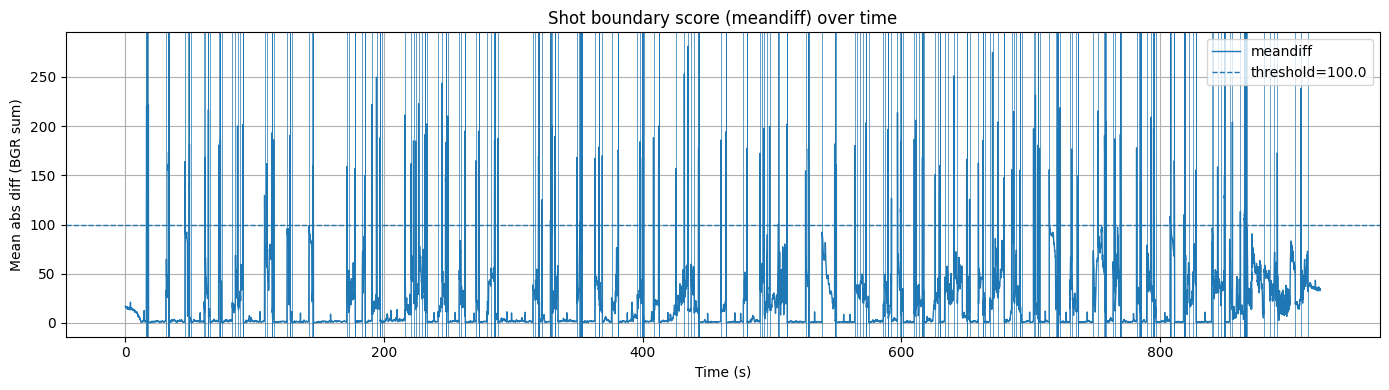

In [10]:
if plot_meandiff:
    base = os.path.splitext(os.path.basename(video_path))[0]
    plot_path = os.path.join("plots", base + "_meandiff.png")
    plot_meandiff_func(
        meandiff_series,
        fps=vinfo["fps"],
        diff_threshold=diff_threshold,
        out_path=plot_path,
        max_points=plot_max_points,
        cut_frames=cut_frames,
        show=(not no_popup),
        block=True
    )

results = []
os.makedirs(out_dir, exist_ok=True)

This loop iterates over all detected shots, extracts per-shot features and clips, then writes a CSV summary and prints the output path.

In [12]:
for s in shots:
    r = analyze_shot(video_path, s, hue_tol=12, sample_step=sample_step)
    if r is None:
        continue

    # Save shot clip
    clip_path = save_shot_clip(video_path, s, vinfo, out_dir)
    results.append((s, r))

    print(f"Shot {s.id}: court_ratio={r['court_ratio']:.3f}, meandiff_mean={r['meandiff_mean']:.2f}, clip={clip_path}")

out_csv = "results/videoTEST02_shots_summary.csv"
summarize_and_save(results, out_csv)
print("Saved summary to", out_csv)

Shot 0: court_ratio=0.551, meandiff_mean=9.18, clip=shots_output\shot_000_000000_000406.mp4
Shot 1: court_ratio=0.095, meandiff_mean=22.33, clip=shots_output\shot_001_000412_000444.mp4
Shot 2: court_ratio=0.730, meandiff_mean=1.30, clip=shots_output\shot_002_000445_000781.mp4
Shot 3: court_ratio=0.365, meandiff_mean=38.23, clip=shots_output\shot_003_000782_000830.mp4
Shot 4: court_ratio=0.182, meandiff_mean=6.15, clip=shots_output\shot_004_000836_000849.mp4
Shot 5: court_ratio=0.644, meandiff_mean=1.86, clip=shots_output\shot_005_000850_001152.mp4
Shot 6: court_ratio=0.140, meandiff_mean=88.49, clip=shots_output\shot_006_001153_001201.mp4
Shot 7: court_ratio=0.301, meandiff_mean=10.41, clip=shots_output\shot_007_001202_001234.mp4
Shot 8: court_ratio=0.207, meandiff_mean=3.93, clip=shots_output\shot_008_001240_001271.mp4
Shot 9: court_ratio=0.731, meandiff_mean=1.64, clip=shots_output\shot_009_001272_001521.mp4
Shot 10: court_ratio=0.208, meandiff_mean=15.65, clip=shots_output\shot_010_

## SHOT IDENTIFICATION

### This code below implements the shot identification pipeline, including:
- Shot-level feature analysis and computation
- Threshold selection
- Shot filtering for candidate retention

The code in the cell below loads the shot summary CSV and visualizes the distribution of shots by plotting **court_ratio**, **meandiff_mean**. The scatter plot helps us identify clusters and choose thresholds for selecting relevant effective-play tennis shots.

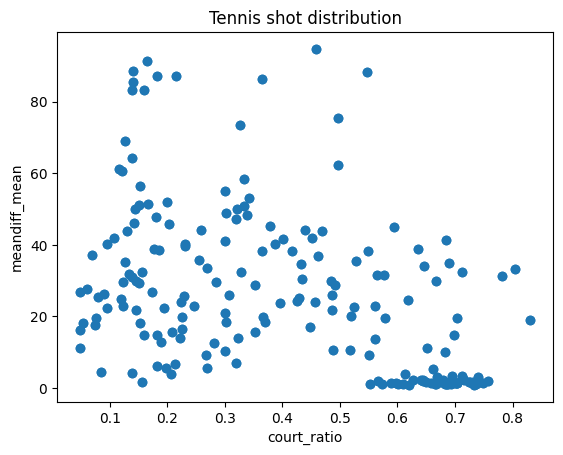

In [13]:
df = pd.read_csv("results/videoTEST02_shots_summary.csv")

plt.scatter(df['court_ratio'], df['meandiff_mean'])
plt.xlabel('court_ratio')
plt.ylabel('meandiff_mean')
plt.title('Tennis shot distribution')
plt.show()

From this scatter plot, we can observe a clear cluster located at high **court_ratio** (around 0.55–0.75) and very low **meandiff_mean** (close to 0–10). Therefore, we manually set the thresholds on **court_ratio** and **meandiff_mean** to filter the shots that are most likely to represent effective-play tennis shots. <br>
Based on this observation, the following thresholds are chosen to filter the shots:
- **court_ratio** > 0.52
- **meandiff_mean** < 10

As the result, we obtain the `videoTEST02_filtered_shots.csv`, which lists the shots selected as effective-play candidates.

In [14]:
df = pd.read_csv("results/videoTEST02_shots_summary.csv")
filtered_df = df[(df['court_ratio'] > 0.52) & (df['meandiff_mean'] < 10)]
print(filtered_df)
filtered_df.to_csv("results/videoTEST02_filtered_shots.csv", index=False)

n_records = df.shape[0]
print(f"Number of records: {n_records}")

     shot_id  start_frame  end_frame  start_time  end_time  duration_s  \
0          0            0        406        0.00     16.24       16.24   
2          2          445        781       17.80     31.24       13.44   
5          5          850       1152       34.00     46.08       12.08   
9          9         1272       1521       50.88     60.84        9.96   
13        13         1638       1804       65.52     72.16        6.64   
..       ...          ...        ...         ...       ...         ...   
363      167        19625      19741      785.00    789.64        4.64   
367      171        19922      20193      796.88    807.72       10.84   
369      173        20279      20453      811.16    818.12        6.96   
374      178        20695      20997      827.80    839.88       12.08   
379      183        21248      21343      849.92    853.72        3.80   

     court_ratio  meandiff_mean  court_hue  
0       0.551241       9.183805         29  
2       0.729741     

After filtering the 196 detected shots, we focus on the remaining effective-play candidates and perform motion analysis using centroid tracking (MOG2 background subtraction). <br/>For each shot, we track the moving player blob and extract motion features such as the maximum forward movement (max advance in y) and the movement towards the image center, which are later combined to rank shots by their likelihood of an approach-to-net action.

#### Function definition
- `_clamp_roi` ensures the Region of Interest coordinates stay inside the image boundaries. If no ROI is provided, the full frame is used. This avoids out-of-range indexing when cropping frames.
- `centroid_track_mog2` tracks the motion centroid within a shot using MOG2 background subtraction:
    - The frame is cropped to the ROI.
    - Foreground pixels are extracted using MOG2, then binarized and cleaned with morphological operations.
    - The largest moving blob (contour) is selected, and its centroid is computed.
    - The function returns a list of centroids (cx,cy) sampled every step frames.
- `zscore` normalizes a feature vector using z-score (x−μ)/σ. This is used to combine features with different scales.
- `sigmoid` maps values to the range [0,1], which is useful as a soft weighting factor.
- `features_maxadvance_and_center` computes two motion cues from the centroid trajectory of each effective-play shot. These features are later combined into a score to rank shots by their likelihood of an approach-to-net action.
    - **max_advance_y_norm** the maximum upward movement during the shot
    - **center_approach_norm** the maximum movement towards the image center


In [15]:
def _clamp_roi(frame_bgr, roi):
    H, W = frame_bgr.shape[:2]
    if roi is None:
        return (0, 0, W, H)
    x0, y0, x1, y1 = roi
    x0 = max(0, min(W-1, int(x0)))
    x1 = max(1, min(W,   int(x1)))
    y0 = max(0, min(H-1, int(y0)))
    y1 = max(1, min(H,   int(y1)))
    return (x0, y0, x1, y1)

def centroid_track_mog2(video_path, start_f, end_f, step=2, roi=None, area_min=300):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return []
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_f)
    ok, frame0 = cap.read()
    if not ok:
        cap.release()
        return []

    x0, y0, x1, y1 = _clamp_roi(frame0, roi)
    bg = cv2.createBackgroundSubtractorMOG2(history=80, varThreshold=25, detectShadows=False)

    centroids = []
    f = start_f
    while f <= end_f:
        cap.set(cv2.CAP_PROP_POS_FRAMES, f)
        ok, frame = cap.read()
        if not ok:
            break

        crop = frame[y0:y1, x0:x1]
        fg = bg.apply(crop)

        _, th = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)
        th = cv2.morphologyEx(th, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
        th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, np.ones((5,5), np.uint8))

        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            area = cv2.contourArea(largest)
            if area >= area_min:
                M = cv2.moments(largest)
                if M["m00"] != 0:
                    cx = int(M["m10"]/M["m00"]) + x0
                    cy = int(M["m01"]/M["m00"]) + y0
                    centroids.append((cx, cy))

        f += step

    cap.release()
    return centroids

def zscore(a):
    a = np.asarray(a, dtype=np.float32)
    m = np.nanmean(a)
    s = np.nanstd(a)
    if s < 1e-8:
        return a - m
    return (a - m) / s

def sigmoid(x):
    x = np.asarray(x, dtype=np.float32)
    return 1.0 / (1.0 + np.exp(-x))

def features_maxadvance_and_center(video_path, start_f, end_f, step, roi, H, W):
    """
    Returns ONLY the 2 key signals you asked for:
      1) max_advance_y_norm: y_ref - min(y(t)) normalized by H
      2) center_approach_norm: |x_ref - x_center| - min|x(t)-x_center| normalized by W
    """
    cents = centroid_track_mog2(video_path, start_f, end_f, step=step, roi=roi, area_min=300)
    if len(cents) < 6:
        return {
            "centroid_count": len(cents),
            "max_advance_y": None,
            "max_advance_y_norm": None,
            "center_approach": None,
            "center_approach_norm": None
        }

    xs = np.array([c[0] for c in cents], dtype=np.float32)
    ys = np.array([c[1] for c in cents], dtype=np.float32)

    n = len(cents)
    k = max(1, n // 5)              # 20% đầu shot
    x_ref = float(np.median(xs[:k]))
    y_ref = float(np.median(ys[:k]))

    # ---- (1) MAX ADVANCE in Y ----
    y_min = float(np.min(ys))
    max_advance_y = y_ref - y_min
    max_advance_y_norm = max_advance_y / float(H)

    # ---- (2) APPROACH TO CENTER in X ----
    x_center = float(W / 2.0)
    d_ref = abs(x_ref - x_center) 
    d_min = float(np.min(np.abs(xs - x_center))) 
    center_approach = d_ref - d_min       
    center_approach_norm = center_approach / float(W)

    return {
        "centroid_count": len(cents),
        "max_advance_y": float(max_advance_y),
        "max_advance_y_norm": float(max_advance_y_norm),
        "center_approach": float(center_approach),
        "center_approach_norm": float(center_approach_norm),
        "x_ref": x_ref,
        "y_ref": y_ref,
        "x_center": x_center,
        "d_ref_center": float(d_ref),
        "d_min_center": float(d_min)
    }

This block loads the effective-play shots from filtered_shots.csv, reads the video size to define a court ROI, and extracts motion features for each shot using `features_maxadvance_and_center`. For every shot, it computes two key signals: maximum forward advance (**max_advance_y_norm**) and movement towards the image center (**center_approach_norm**). <br>
We normalize both features with z-score and use a sigmoid on the center movement as a soft penalty. The final score is: **approach_score=z(max_advance_y_norm)×sigmoid(z(center_approach_norm))**.


In [ ]:
video_path = "video_files/videoTEST02.mp4"
df_eff = pd.read_csv("results/videoTEST02_filtered_shots.csv")

cap = cv2.VideoCapture(video_path)
ok, fr0 = cap.read()
cap.release()
if not ok:
    raise RuntimeError("Cannot read first frame.")
H, W = fr0.shape[:2]

roi = (int(0.10*W), int(0.35*H), int(0.90*W), int(0.95*H))

rows = []
for _, r in df_eff.iterrows():
    start_f = int(r["start_frame"])
    end_f   = int(r["end_frame"])
    feat = features_maxadvance_and_center(video_path, start_f, end_f, step=2, roi=roi, H=H, W=W)
    rows.append({**r.to_dict(), **feat})

dfF = pd.DataFrame(rows)

# --- Build approach_score from ONLY 2 signals ---
# Normalize each signal by z-score (so they are comparable)
dfF["z_maxadv"] = zscore(dfF["max_advance_y_norm"].to_numpy())
dfF["z_center"] = zscore(dfF["center_approach_norm"].to_numpy())

# Penalty/boost factor from center movement (0..1)
# If z_center is negative -> factor < 0.5, score reduced
dfF["center_factor"] = sigmoid(dfF["z_center"])

# Final score: strong max advance BUT penalize if not moving towards center
dfF["approach_score"] = dfF["z_maxadv"] * dfF["center_factor"]

# Rank
df_ranked = dfF.sort_values("approach_score", ascending=False).reset_index(drop=True)

out_path = "results/effective_play_ranked_approach_net.csv"
df_ranked.to_csv(out_path, index=False)
print("Saved:", out_path)

# Show top 15
cols = ["shot_id","start_time","end_time",
        "approach_score",
        "max_advance_y_norm","center_approach_norm","center_factor",
        "centroid_count"]
df_ranked[cols].head(15)

Saved: effective_play_ranked_approach_net.csv


,shot_id,start_time,end_time,approach_score,max_advance_y_norm,center_approach_norm,center_factor,centroid_count
0,161.0,758.36,763.64,1.601361,0.394444,0.251563,0.763111,45
1,161.0,758.36,763.64,1.601361,0.394444,0.251563,0.763111,45
2,76.0,368.76,375.88,1.478485,0.394444,0.223438,0.704556,78
3,76.0,368.76,375.88,1.478485,0.394444,0.223438,0.704556,78
4,65.0,322.28,328.60,1.219107,0.337500,0.287500,0.825501,80
5,65.0,322.28,328.60,1.219107,0.337500,0.287500,0.825501,80
6,61.0,288.04,315.00,1.173661,0.358333,0.216406,0.688670,310
7,61.0,288.04,315.00,1.173661,0.358333,0.216406,0.688670,310
8,124.0,617.76,626.16,1.168772,0.334722,0.276562,0.808009,91
9,124.0,617.76,626.16,1.168772,0.334722,0.276562,0.808009,91


Finally, the shots are sorted by **approach_score** in descending order, saved to **effective_play_ranked_approach_net.csv**, and the top-ranked candidates are displayed.